In [1]:
import pandas as pd

# Load CSV (make sure you have downloaded it from Kaggle)
data = pd.read_csv("Financial.csv")

# Quick overview
print(data.shape)
print(data.columns)
print(data['isFraud'].value_counts(normalize=True))  # check class imbalance


(6362620, 11)
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [2]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
import numpy as np

# Log transform amount to reduce skew
data['amt_log'] = np.log1p(data['amount'])

# Balance differences
data['diff_orig'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['diff_dest'] = data['newbalanceDest'] - data['oldbalanceDest']

# Flag if sender and receiver are the same
data['same_account'] = (data['nameOrig'] == data['nameDest']).astype(int)

# Extract hour of the transaction
data['hour'] = data['step'] % 24

# Encode transaction type as categorical codes
data['type_code'] = data['type'].astype('category').cat.codes

data.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amt_log,diff_orig,diff_dest,same_account,hour,type_code
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9.194276,9839.64,0.0,0,1,3
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,7.531166,1864.28,0.0,0,1,3
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,5.204007,181.00,0.0,0,1,4
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,5.204007,181.00,-21182.0,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,9.364703,11668.14,0.0,0,1,3


In [5]:
from sklearn.preprocessing import KBinsDiscretizer

disc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

for col in ['amt_log','diff_orig','diff_dest']:
    data[col + '_disc'] = disc.fit_transform(data[[col]]).astype(int).ravel()

data[['amt_log_disc','diff_orig_disc','diff_dest_disc']].head()


c:\Users\Morvica\OneDrive\Desktop\Morvica\Online_Payment_Fraud_Prediction\bnv_env\lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


,amt_log_disc,diff_orig_disc,diff_dest_disc
0,0,3,1
1,0,3,1
2,0,2,1
3,0,2,0
4,1,3,1


In [6]:
cols = ['type_code', 'amt_log_disc', 'diff_orig_disc', 'diff_dest_disc', 'same_account', 'hour', 'isFraud']
df_bn = data[cols].copy()

# Convert to categorical codes (required by pgmpy)
df_bn = df_bn.apply(lambda s: s.astype('category').cat.codes)


In [7]:
df_bn.head()

,type_code,amt_log_disc,diff_orig_disc,diff_dest_disc,same_account,hour,isFraud
0,3,0,3,1,0,1,0
1,3,0,3,1,0,1,0
2,4,0,2,1,0,1,1
3,1,0,2,0,0,1,1
4,3,1,3,1,0,1,0


In [11]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Assume df_bn is your original dataset and 'isFraud' is your label
X = df_bn.drop('isFraud', axis=1)
y = df_bn['isFraud']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recreate balanced dataframe
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns),
                          pd.Series(y_resampled, name='isFraud')], axis=1)

print("✅ After SMOTE balancing:")
print(df_resampled['isFraud'].value_counts())

c:\Users\Morvica\OneDrive\Desktop\Morvica\Online_Payment_Fraud_Prediction\bnv_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


✅ After SMOTE balancing:
isFraud
0    6354407
1    6354407
Name: count, dtype: int64


In [49]:
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork

# 1️⃣ Sample the dataset to speed up structure learning
df_sample = df_resampled.sample(n=636262, random_state=42)

# 2️⃣ Initialize Hill Climb Search
hc = HillClimbSearch(df_sample)
scoring = BicScore(df_sample)

# 3️⃣ Custom loop to show progress across iterations
best_model = None
best_score = float("-inf")

print("Starting Hill Climb Search...\n")

# Run for 100 epochs (or until convergence)
for i in range(1, 101):  
    model = hc.estimate(scoring_method=scoring,
                        max_indegree=3,
                        max_iter=i)  # increase iter gradually

    score = scoring.score(model)

    if score > best_score:
        best_score = score
        best_model = model

    print(f"Epoch {i:03d}: BIC Score = {score:.2f}, Edges = {list(model.edges())}")

print("\n✅ Final Best Structure:")
print(best_model.edges())
print(f"Final BIC Score = {best_score:.2f}")


Starting Hill Climb Search...



100%|██████████| 1/1 [00:01<00:00,  1.56s/it]


Epoch 001: BIC Score = -5297261.50, Edges = [('diff_dest_disc', 'type_code')]


100%|██████████| 2/2 [00:01<00:00,  1.18it/s]


Epoch 002: BIC Score = -4989470.83, Edges = [('type_code', 'diff_orig_disc'), ('diff_dest_disc', 'type_code')]


...

Epoch 098: BIC Score = -4068783.31, Edges = [('type_code', 'diff_orig_disc'), ('type_code', 'isFraud'), ('type_code', 'amt_log_disc'), ('amt_log_disc', 'hour'), ('diff_orig_disc', 'isFraud'), ('diff_orig_disc', 'amt_log_disc'), ('diff_dest_disc', 'type_code'), ('diff_dest_disc', 'amt_log_disc'), ('diff_dest_disc', 'isFraud'), ('diff_dest_disc', 'diff_orig_disc'), ('diff_dest_disc', 'hour'), ('isFraud', 'hour')]


 12%|█▏        | 12/99 [00:07<00:54,  1.59it/s]


Epoch 099: BIC Score = -4068783.31, Edges = [('type_code', 'diff_orig_disc'), ('type_code', 'isFraud'), ('type_code', 'amt_log_disc'), ('amt_log_disc', 'hour'), ('diff_orig_disc', 'isFraud'), ('diff_orig_disc', 'amt_log_disc'), ('diff_dest_disc', 'type_code'), ('diff_dest_disc', 'amt_log_disc'), ('diff_dest_disc', 'isFraud'), ('diff_dest_disc', 'diff_orig_disc'), ('diff_dest_disc', 'hour'), ('isFraud', 'hour')]


 12%|█▏        | 12/100 [00:08<01:00,  1.45it/s]


Epoch 100: BIC Score = -4068783.31, Edges = [('type_code', 'diff_orig_disc'), ('type_code', 'isFraud'), ('type_code', 'amt_log_disc'), ('amt_log_disc', 'hour'), ('diff_orig_disc', 'isFraud'), ('diff_orig_disc', 'amt_log_disc'), ('diff_dest_disc', 'type_code'), ('diff_dest_disc', 'amt_log_disc'), ('diff_dest_disc', 'isFraud'), ('diff_dest_disc', 'diff_orig_disc'), ('diff_dest_disc', 'hour'), ('isFraud', 'hour')]

✅ Final Best Structure:
[('type_code', 'diff_orig_disc'), ('type_code', 'isFraud'), ('type_code', 'amt_log_disc'), ('amt_log_disc', 'hour'), ('diff_orig_disc', 'isFraud'), ('diff_orig_disc', 'amt_log_disc'), ('diff_dest_disc', 'type_code'), ('diff_dest_disc', 'amt_log_disc'), ('diff_dest_disc', 'isFraud'), ('diff_dest_disc', 'diff_orig_disc'), ('diff_dest_disc', 'hour'), ('isFraud', 'hour')]
Final BIC Score = -4068783.31


In [50]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import pandas as pd
import itertools

# -----------------------------
#  Use the learned edges from HillClimbSearch
# -----------------------------
edges = list(best_model.edges())
print("Learned edges:", edges)

# -----------------------------
# Create Bayesian Network with learned structure
# -----------------------------
model = BayesianNetwork(edges)

# -----------------------------
# Fit CPDs using Maximum Likelihood Estimator
# -----------------------------
model.fit(df_resampled, estimator=MaximumLikelihoodEstimator)
print("\n CPDs learned successfully.\n")

# # Print all CPDs 
# print("📊 Conditional Probability Distributions (CPDs):\n")
# for cpd in model.get_cpds():
#     print(f"CPD of {cpd.variable}:")

#     # Get the CPD as a DataFrame with multi-index for parent values
#     df_cpd = cpd.to_dataframe().reset_index()

#     # Rename the last column to 'Probability'
#     df_cpd = df_cpd.rename(columns={df_cpd.columns[-1]: 'Probability'})

#     print(df_cpd)
#     print("-" * 80)

infer = VariableElimination(model)

# -----------------------------
# Example transaction evidence (you can change values)
# -----------------------------
example_evidence = {
    'type_code': 0,
    'amt_log_disc': 2,
    'diff_orig_disc': 3,
    'diff_dest_disc': 0,
    'hour': 20
}

result = infer.query(variables=['isFraud'], evidence=example_evidence)
print("\n Fraud Probability Inference for example evidence:")
print("Evidence:", example_evidence)
print("P(isFraud=0) =", result.values[0])
print("P(isFraud=1) =", result.values[1])
print("-" * 80)



Learned edges: [('type_code', 'diff_orig_disc'), ('type_code', 'isFraud'), ('type_code', 'amt_log_disc'), ('amt_log_disc', 'hour'), ('diff_orig_disc', 'isFraud'), ('diff_orig_disc', 'amt_log_disc'), ('diff_dest_disc', 'type_code'), ('diff_dest_disc', 'amt_log_disc'), ('diff_dest_disc', 'isFraud'), ('diff_dest_disc', 'diff_orig_disc'), ('diff_dest_disc', 'hour'), ('isFraud', 'hour')]

 CPDs learned successfully.


 Fraud Probability Inference for example evidence:
Evidence: {'type_code': 0, 'amt_log_disc': 2, 'diff_orig_disc': 3, 'diff_dest_disc': 0, 'hour': 20}
P(isFraud=0) = 0.9891557394104047
P(isFraud=1) = 0.010844260589595322
--------------------------------------------------------------------------------


In [51]:
print("Edges in your BN:")
for edge in model.edges():
    print(edge)


Edges in your BN:
('type_code', 'diff_orig_disc')
('type_code', 'isFraud')
('type_code', 'amt_log_disc')
('diff_orig_disc', 'isFraud')
('diff_orig_disc', 'amt_log_disc')
('isFraud', 'hour')
('amt_log_disc', 'hour')
('diff_dest_disc', 'type_code')
('diff_dest_disc', 'amt_log_disc')
('diff_dest_disc', 'isFraud')
('diff_dest_disc', 'diff_orig_disc')
('diff_dest_disc', 'hour')


In [52]:
import pandas as pd
import itertools

def cpd_to_dataframe(cpd):
    """
    Convert a TabularCPD to a readable pandas DataFrame.
    Works even if state_names is None (numeric variables).
    """
    var = cpd.variable
    # If state_names exists, use it; else create numeric labels
    if cpd.state_names and var in cpd.state_names:
        var_states = cpd.state_names[var]
    else:
        var_states = list(range(cpd.cardinality[cpd.variables.index(var)]))

    parents = cpd.variables[1:]  # first is the variable itself
    parent_states = []
    for p in parents:
        if cpd.state_names and p in cpd.state_names:
            parent_states.append(cpd.state_names[p])
        else:
            parent_states.append(list(range(cpd.cardinality[cpd.variables.index(p)])))

    values = cpd.get_values()

    if len(parents) > 0:
        combos = list(itertools.product(*parent_states))
        rows = []
        for i, combo in enumerate(combos):
            for j, state in enumerate(var_states):
                row = dict(zip(parents, combo))
                row[var] = state
                row['Probability'] = values[j, i]
                rows.append(row)
        df = pd.DataFrame(rows)
    else:
        df = pd.DataFrame({
            var: var_states,
            'Probability': values.flatten()
        })
    return df

# Print CPDs
cpds = model.get_cpds()
if not cpds:
    print("No CPDs found! Make sure the model is fitted properly.")
else:
    for cpd in cpds:
        print(f"CPD of {cpd.variable}:")
        df_cpd = cpd_to_dataframe(cpd)
        print(df_cpd)
        print("-" * 80)


CPD of type_code:
    diff_dest_disc  type_code  Probability
0                0          0     0.947377
1                0          1     0.047769
2                0          2     0.001137
3                0          3     0.000000
4                0          4     0.003716
5                1          0     0.027314
6                1          1     0.079816
7                1          2     0.006222
8                1          3     0.358012
9                1          4     0.528635
10               2          0     0.008966
11               2          1     0.938397
12               2          2     0.000775
13               2          3     0.000000
14               2          4     0.051862
15               3          0     0.006570
16               3          1     0.871532
17               3          2     0.000298
18               3          3     0.000000
19               3          4     0.121600
-------------------------------------------------------------------------------

In [53]:
import pickle

# Save
with open("fraud_bn.pkl", "wb") as f:
    pickle.dump(model, f)

# Load
with open("fraud_bn.pkl", "rb") as f:
    loaded_model = pickle.load(f)


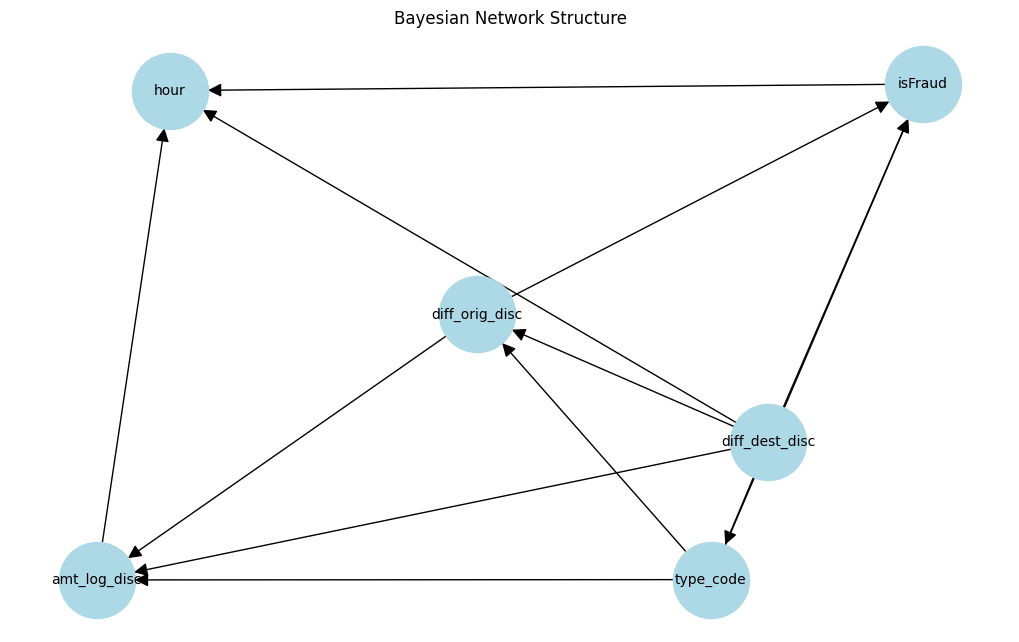

In [54]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph from edges
G = nx.DiGraph()
G.add_edges_from(model.edges())

# Draw the network
plt.figure(figsize=(10,6))
nx.draw(G, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, arrowsize=20)
plt.title("Bayesian Network Structure")
plt.show()


In [55]:
for cpd in model.get_cpds():
    print(cpd.variable, cpd.state_names)


type_code {'type_code': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)], 'diff_dest_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3)]}
diff_orig_disc {'diff_orig_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)], 'diff_dest_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3)], 'type_code': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]}
isFraud {'isFraud': [np.int8(0), np.int8(1)], 'diff_dest_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3)], 'diff_orig_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)], 'type_code': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]}
amt_log_disc {'amt_log_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)], 'diff_dest_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3)], 'diff_orig_disc': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)], 'type_code': [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]}
hour {'hour': [np.int8(

In [56]:
import pandas as pd
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

# Load your dataset
# df_bn = pd.read_csv("paysim_sample.csv")  # or your preprocessed BN dataset

# Define your BN edges (manual or learned)
edges = edges = list(best_model.edges())
model = BayesianNetwork(edges)

# ✅ Fit the model with explicit state names to include all possible values
model.fit(df_resampled, estimator=MaximumLikelihoodEstimator, state_names={
    'type_code': [0,1,2,3,4],
    'amt_log_disc': [0,1,2,3,4],
    'diff_orig_disc': [0,1,2,3,4],
    'diff_dest_disc': [0,1,2,3],
    'hour': list(range(24)),
    'isFraud': [0,1]
})

# Create inference object
infer = VariableElimination(model)

# Now you can query without KeyErrors


In [57]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'fraud.pkl')

print("Model saved as 'fraud.pkl'")


Model saved as 'fraud.pkl'


In [60]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Performance evaluation of biased dataset

# Use a test dataset (can be the same or a hold-out portion)
test_df = df_bn.sample(636262, random_state=42)  # Example: 1000 rows

# Lists to store true labels and predictions
y_true = []
y_pred = []

for idx, row in test_df.iterrows():
    # Prepare evidence from the row
    evidence = {
        'type_code': row['type_code'],
        'amt_log_disc': row['amt_log_disc'],
        'diff_orig_disc': row['diff_orig_disc'],
        'diff_dest_disc': row['diff_dest_disc'],
        'hour': row['hour']
    }
    
    # Query the trained model
    result = infer.query(variables=['isFraud'], evidence=evidence, show_progress=False)
    
    # Predicted class: pick class with maximum probability
    pred_class = result.values.argmax()  # 0 or 1
    y_pred.append(pred_class)
    y_true.append(row['isFraud'])

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Performance Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Performance Metrics:
Accuracy  : 0.9028
Precision : 0.0126
Recall    : 0.9645
F1-score  : 0.0249


In [62]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Performance evaluation of balanced dataset

# Use a test dataset (can be the same or a hold-out portion)
test_df = df_resampled.sample(636262, random_state=42)  # Example: 1000 rows

# Lists to store true labels and predictions
y_true = []
y_pred = []

for idx, row in test_df.iterrows():
    # Prepare evidence from the row
    evidence = {
        'type_code': row['type_code'],
        'amt_log_disc': row['amt_log_disc'],
        'diff_orig_disc': row['diff_orig_disc'],
        'diff_dest_disc': row['diff_dest_disc'],
        'hour': row['hour']
    }
    
    # Query the trained model
    result = infer.query(variables=['isFraud'], evidence=evidence, show_progress=False)
    
    # Predicted class: pick class with maximum probability
    pred_class = result.values.argmax()  # 0 or 1
    y_pred.append(pred_class)
    y_true.append(row['isFraud'])

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Performance Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Performance Metrics:
Accuracy  : 0.9358
Precision : 0.9086
Recall    : 0.9687
F1-score  : 0.9377
